# Cricket Ball & Bat Detection

Detect cricket **ball** and **bat** in videos from `labelled/` and `labelled 2/` using trained models **ball_best.pt** and **bat_best.pt** (YOLOv8).

**Dependencies:** `pip install opencv-python numpy ultralytics matplotlib`

## 1. Setup & Configuration

In [6]:
import cv2
import numpy as np
import os
import re
from pathlib import Path
from IPython.display import Video, display

# Base directory (where this notebook lives)
BASE_DIR = Path.cwd()  # Run from project root (labelled videos folder)

# Input folders
LABELLED_DIR = BASE_DIR / 'labelled'
LABELLED2_DIR = BASE_DIR / 'labelled 2'

# Output folder for detection results
OUTPUT_DIR = BASE_DIR / 'detection_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Test config: 5 videos per folder
SAMPLE_SIZE = 5

# Video extensions
VIDEO_EXTENSIONS = {'.mp4', '.avi', '.mov', '.mkv', '.webm'}

print(f'Base dir: {BASE_DIR}')
print(f'labelled exists: {LABELLED_DIR.exists()}')
print(f'labelled 2 exists: {LABELLED2_DIR.exists()}')

Base dir: c:\Users\PC\Documents\Internship work\labelled videos
labelled exists: True
labelled 2 exists: True


In [7]:
def collect_video_files(*root_dirs, recursive=True):
    """Collect video file paths from one or more directories."""
    videos = []
    for root in root_dirs:
        root = Path(root)
        if not root.exists():
            continue
        if recursive:
            for f in root.rglob('*'):
                if f.is_file() and f.suffix.lower() in VIDEO_EXTENSIONS:
                    videos.append(f)
        else:
            for f in root.iterdir():
                if f.is_file() and f.suffix.lower() in VIDEO_EXTENSIONS:
                    videos.append(f)
    return videos

def sample_videos_per_folder(video_list, sample_size=5):
    """Group videos by their parent folder and sample N from each group."""
    groups = {}
    for v in video_list:
        parent = v.parent
        if parent not in groups:
            groups[parent] = []
        groups[parent].append(v)

    sampled = []
    for parent, files in groups.items():
        files_sorted = sorted(files, key=lambda x: x.name)
        sampled.extend(files_sorted[:sample_size])
    return sampled

# Collect all videos
all_labelled = collect_video_files(LABELLED_DIR)
all_labelled2 = collect_video_files(LABELLED2_DIR)

# For testing: 5 from labelled, 5 from labelled 2 (simple) or 5 per subfolder (comprehensive)
use_simple_sampling = True  # Set False for 5 per subfolder in labelled 2
if use_simple_sampling:
    labelled_sample = sorted(all_labelled, key=lambda x: x.name)[:SAMPLE_SIZE]
    labelled2_sample = sorted(all_labelled2, key=lambda x: x.name)[:SAMPLE_SIZE]
else:
    labelled_sample = sample_videos_per_folder(all_labelled, SAMPLE_SIZE)
    labelled2_sample = sample_videos_per_folder(all_labelled2, SAMPLE_SIZE)

test_videos = labelled_sample + labelled2_sample
print(f'Total videos to process: {len(test_videos)}')
for v in test_videos[:12]:
    try:
        print(f'  - {v.relative_to(BASE_DIR)}')
    except ValueError:
        print(f'  - {v}')

Total videos to process: 10
  - labelled\delivery_001_BAT[straight-drive_third-man_middled_RHB]_BOWL[good_middle-stump_straight-ball_none_LAF]_correct.mp4
  - labelled\delivery_002_BAT[glance_square-leg_mistimed_RHB]_BOWL[good_leg-stump_seam-in_moderate_LAF]_correct.mp4
  - labelled\delivery_003_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled\delivery_004_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled\delivery_005_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled 2\delivery_001_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled 2\Local\delivery_001_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled 2\Local 2\delivery_001_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled 2\Local 3\delivery_001_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4
  - labelled 2\delivery_002_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong.mp4


## 2. Ball & Bat Detection (ball_best.pt, bat_best.pt)

In [ ]:
# Ball and bat detection using trained models (YOLOv8)
from ultralytics import YOLO

BALL_WEIGHTS = BASE_DIR / "ball_best.pt"
BAT_WEIGHTS = BASE_DIR / "bat_best.pt"
CONF_THRESHOLD_BALL = 0.45
CONF_THRESHOLD_BAT = 0.5

model_ball = YOLO(str(BALL_WEIGHTS))
model_bat = YOLO(str(BAT_WEIGHTS)) if BAT_WEIGHTS.exists() else None

def detect_ball_in_frame(frame, prev_center=None, max_motion=140):
    """
    Detect cricket ball using YOLO model (ball_best.pt).
    Returns (center, radius) or None.
    """
    results = model_ball.predict(frame, conf=CONF_THRESHOLD_BALL, verbose=False)
    if not results or len(results) == 0:
        return None
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None

    detected = []
    xyxy = boxes.xyxy.cpu().numpy()
    confs = boxes.conf.cpu().numpy()
    for (x1, y1, x2, y2), conf in zip(xyxy, confs):
        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        w, h = x2 - x1, y2 - y1
        radius = max(1, int(max(w, h) / 2))
        detected.append(((cx, cy), radius, float(conf)))

    if not detected:
        return None

    if prev_center and len(detected) > 1:
        px, py = prev_center
        def dist(d):
            cx, cy = d[0]
            return ((cx - px)**2 + (cy - py)**2)**0.5
        within = [d for d in detected if dist(d) <= max_motion]
        if within:
            best = min(within, key=lambda d: (dist(d), -d[2]))
        else:
            best = max(detected, key=lambda d: d[2])
    else:
        best = max(detected, key=lambda d: d[2])

    return (best[0], best[1])


def detect_bat_in_frame(frame):
    """
    Detect cricket bat using YOLO model (bat_best.pt).
    Returns list of (x1, y1, x2, y2) in pixel coords, or [] if no bat model or no detections.
    """
    if model_bat is None:
        return []
    results = model_bat.predict(frame, conf=CONF_THRESHOLD_BAT, verbose=False)
    if not results or len(results) == 0:
        return []
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return []
    xyxy = boxes.xyxy.cpu().numpy()
    return [tuple(map(int, (x1, y1, x2, y2))) for x1, y1, x2, y2 in xyxy]


def process_video(video_path, output_path=None, fps=None):
    """Process a single video: detect ball, draw bboxes, save output video."""
    video_path = Path(video_path)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f'Error opening: {video_path}')
        return []
    if fps is None:
        fps = cap.get(cv2.CAP_PROP_FPS) or 20

    frames_out = []
    size = None
    prev_center = None
    miss_count = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if size is None:
            size = (frame.shape[1], frame.shape[0])

        result = detect_ball_in_frame(frame, prev_center=prev_center)
        if result:
            prev_center = result[0]
            miss_count = 0
        else:
            miss_count += 1
            if miss_count > 8:
                prev_center = None  # Reset; ball may be occluded or out of frame
        img = frame.copy()
        # Bat detections (draw first so ball can overlay)
        bat_boxes = detect_bat_in_frame(frame)
        for (x1, y1, x2, y2) in bat_boxes:
            cv2.rectangle(img, (x1, y1), (x2, y2), (0, 165, 255), 2)  # Orange
            cv2.putText(img, 'Bat', (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 165, 255), 1)
        # Ball detection
        if result:
            center, radius = result
            cv2.circle(img, center, radius, (255, 0, 0), 2)
            w, h = 4 * radius, 4 * radius
            x, y = center
            cv2.rectangle(img, (x - w // 2, y - h // 2), (x + w // 2, y + h // 2), (0, 0, 255), 2)
            cv2.putText(img, 'Ball', (x - w // 2, y - h // 2 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        frames_out.append(img)

    cap.release()

    if output_path and frames_out:
        out = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*'mp4v'), fps, size)
        for f in frames_out:
            out.write(f)
        out.release()
        print(f'Saved: {output_path}')

    return frames_out

## 3. Run Detection on Sampled Videos

In [9]:
results = []
for vpath in test_videos:
    try:
        rel = vpath.relative_to(BASE_DIR)
    except ValueError:
        rel = Path(vpath.name)
    out_name = str(rel).replace(os.sep, '_').replace(' ', '_')
    out_name = re.sub(r'[<>:"|?*]', '', out_name)
    if not out_name.lower().endswith('.mp4'):
        out_name = Path(out_name).stem + '_detected.mp4'
    else:
        out_name = Path(out_name).stem + '_detected.mp4'

    out_path = OUTPUT_DIR / out_name
    frames = process_video(vpath, output_path=out_path)
    results.append({'path': vpath, 'output': out_path, 'frames': len(frames)})

print(f'\nProcessed {len(results)} videos. Outputs in: {OUTPUT_DIR}')

Saved: c:\Users\PC\Documents\Internship work\labelled videos\detection_output\labelled_delivery_001_BAT[straight-drive_third-man_middled_RHB]_BOWL[good_middle-stump_straight-ball_none_LAF]_correct_detected.mp4
Saved: c:\Users\PC\Documents\Internship work\labelled videos\detection_output\labelled_delivery_002_BAT[glance_square-leg_mistimed_RHB]_BOWL[good_leg-stump_seam-in_moderate_LAF]_correct_detected.mp4
Saved: c:\Users\PC\Documents\Internship work\labelled videos\detection_output\labelled_delivery_003_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong_detected.mp4
Saved: c:\Users\PC\Documents\Internship work\labelled videos\detection_output\labelled_delivery_004_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong_detected.mp4
Saved: c:\Users\PC\Documents\Internship work\labelled videos\detection_output\labelled_delivery_005_BAT[na_na_na_na]_BOWL[na_na_na_na_na]_wrong_detected.mp4
Saved: c:\Users\PC\Documents\Internship work\labelled videos\detection_output\labelled_2_delivery_001_BAT[na_na_na_na]_B

## 4. Preview Results

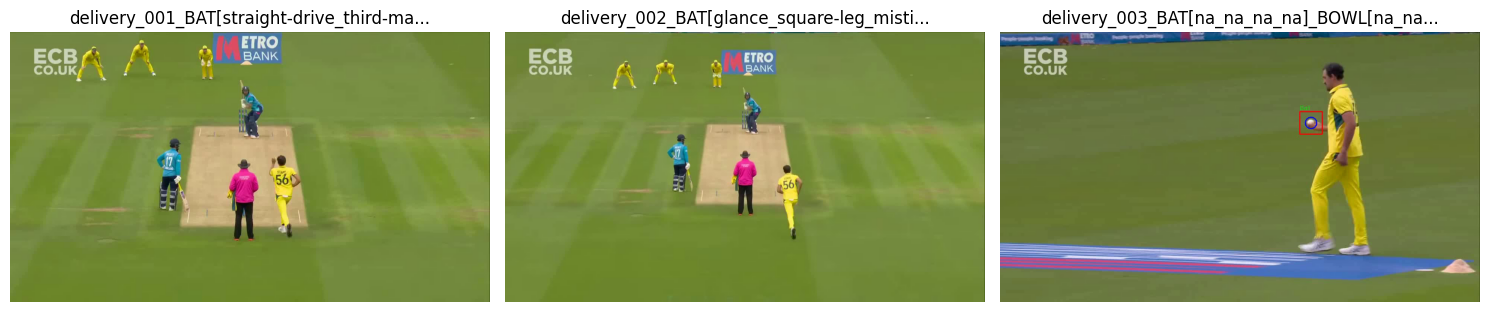

In [10]:
import matplotlib.pyplot as plt
%matplotlib inline

display_count = min(3, len(results)) if results else 0
if display_count == 0:
    print('No results to display.')
else:
    fig, axes = plt.subplots(1, display_count, figsize=(5 * max(display_count, 1), 4))
    if display_count == 1:
        axes = [axes]
    for i, res in enumerate(results[:display_count]):
        cap = cv2.VideoCapture(str(res['output']))
        ret, frame = cap.read()
        cap.release()
        if ret:
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(rgb)
            axes[i].set_title(Path(res['path']).name[:40] + '...' if len(Path(res['path']).name) > 40 else Path(res['path']).name)
            axes[i].axis('off')
    plt.tight_layout()
    plt.show()